**Flight Booking Price Prediction**

**Description**: The objective is to analyze the flight booking dataset sourced from an online ticketing platform, containing over 300,000 records with 11 attributes. A thorough study of the data will aid in the discovery of valuable insights that will be of enormous value to passengers. Apply EDA statistical methods and Machine learning algorithms in order to get meaningful information from it.


In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv("Flight_Booking.csv")
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [13]:
df.drop(columns = ['Unnamed: 0'],inplace = True)

In [14]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [15]:
print("Shape of Dataset (Rows, Columns) : ", df.shape)

Shape of Dataset (Rows, Columns) :  (300153, 11)


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [17]:
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [18]:
df.isnull().sum()

,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0
days_left,0


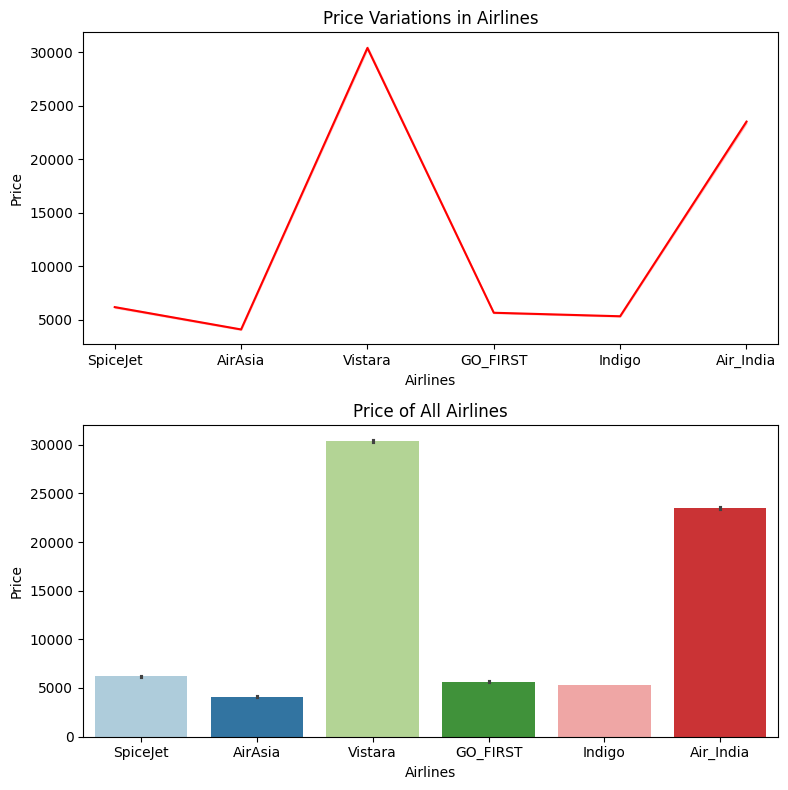

In [19]:

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 8))

# First subplot: Line plot (Price variations in Airlines)
sns.lineplot(x=df['airline'], y=df['price'], color = 'r', ax=axes[0])
axes[0].set_xlabel('Airlines')
axes[0].set_ylabel('Price')
axes[0].set_title('Price Variations in Airlines')

# Second subplot: Bar plot (Price of all airlines)
sns.barplot(x='airline', y='price', palette = "Paired", hue = 'airline', legend=False, data=df, ax=axes[1])
axes[1].set_xlabel('Airlines')
axes[1].set_ylabel('Price')
axes[1].set_title('Price of All Airlines')

# Adjust layout
plt.tight_layout()
plt.show()



*   There is a variation in price with different airline

*   Vistara has the highest price followed by Air_Indias



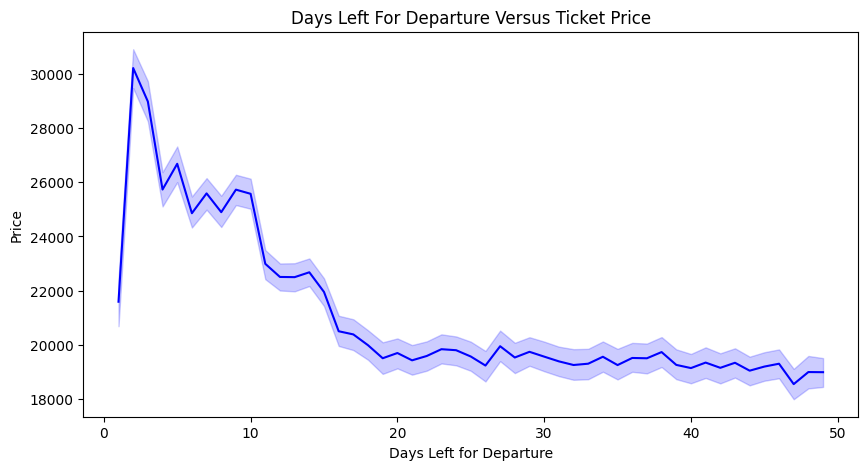

The price of the ticket increases as the days left for departure decreases


In [20]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='days_left', y='price', color='blue')
plt.title('Days Left For Departure Versus Ticket Price')
plt.xlabel('Days Left for Departure')
plt.ylabel('Price')
plt.show()

print("The price of the ticket increases as the days left for departure decreases")

The price of the ticket increases as the days left for departure decreases

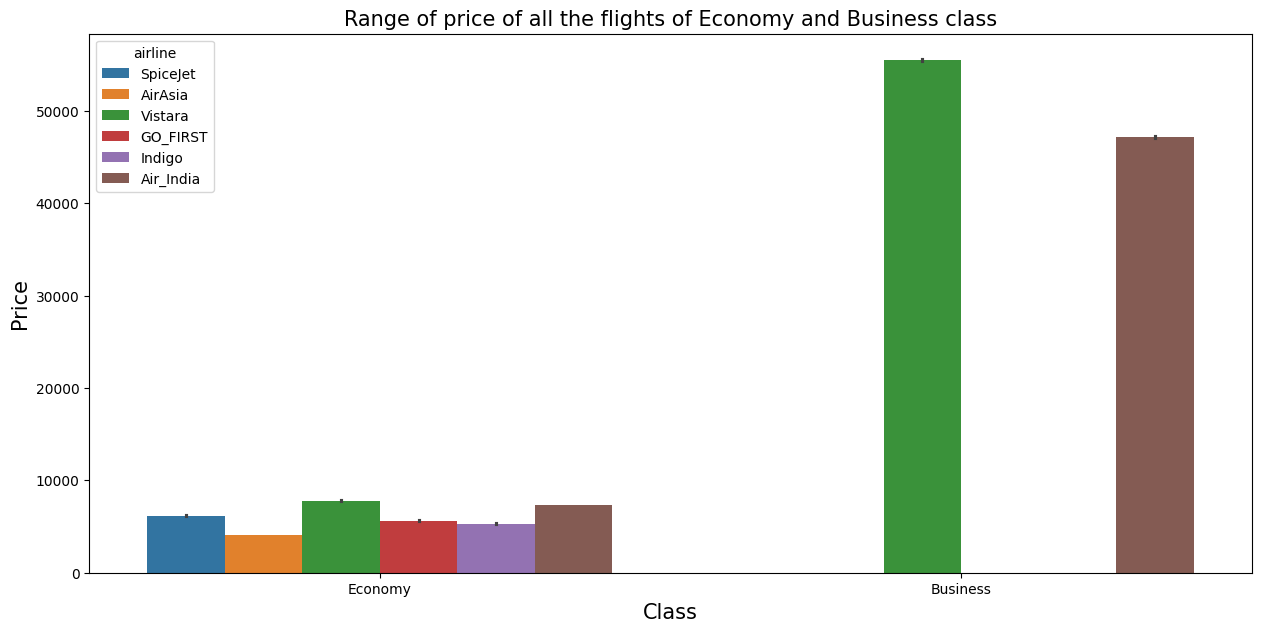

In [22]:
plt.figure(figsize=(15,7))
sns.barplot(x='class',y='price',data=df,hue='airline')
plt.xlabel('Class',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.title('Range of price of all the flights of Economy and Business class',fontsize=15)
plt.show()

Prices of Business class are much higher than economy class.

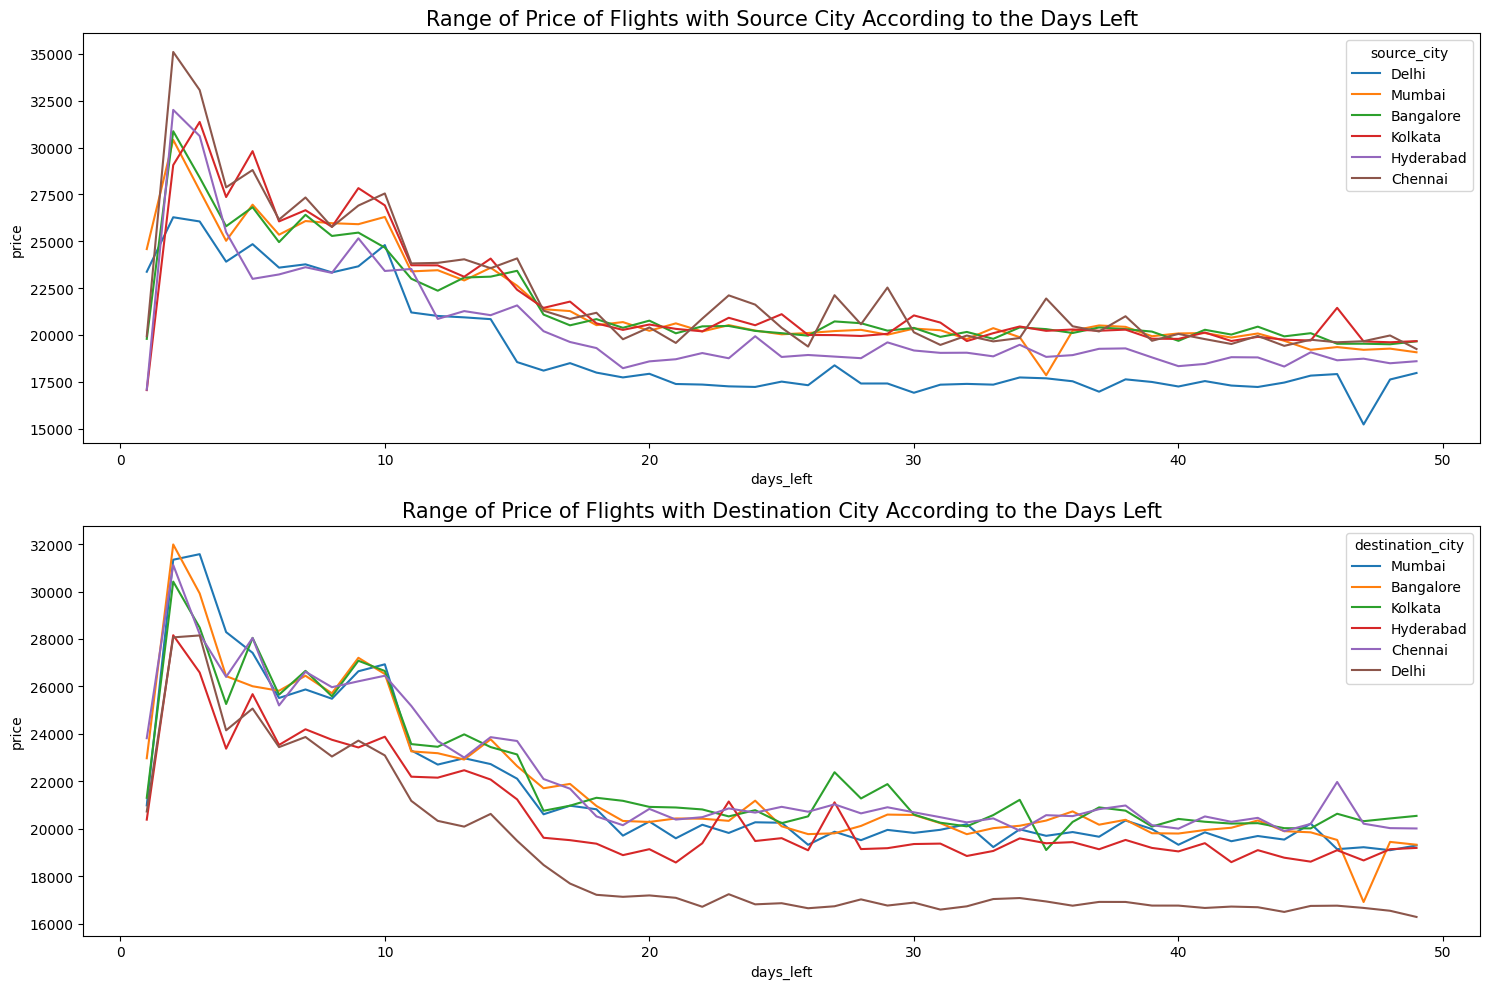

In [23]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(15, 10))

# First subplot: Line plot for source_city
sns.lineplot(x='days_left',y='price',data=df,hue='source_city',ax=ax[0],errorbar=None)
ax[0].set_title('Range of Price of Flights with Source City According to the Days Left', fontsize=15)

# Second subplot: Line plot for destination_city
sns.lineplot(x='days_left',y='price',data=df,hue='destination_city',ax=ax[1],errorbar=None)
ax[1].set_title('Range of Price of Flights with Destination City According to the Days Left', fontsize=15)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()



*  Flight Prices Are Highest Closer to Departure
*   Prices Drop Sharply as Days Increase, afte days left > 20 prices stabalize across all cities
*   Booking early (20+ days in advance) ensures lower prices.
*   Last-minute bookings lead to significantly higher costs.





/tmp/ipykernel_584/1952809738.py:33: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.countplot(x=df["stops"], data=df, hue=df["stops"], palette=palette, legend=False)
/tmp/ipykernel_584/1952809738.py:54: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.countplot(x=df["class"], data=df, hue=df["class"], palette=palette, legend=False)


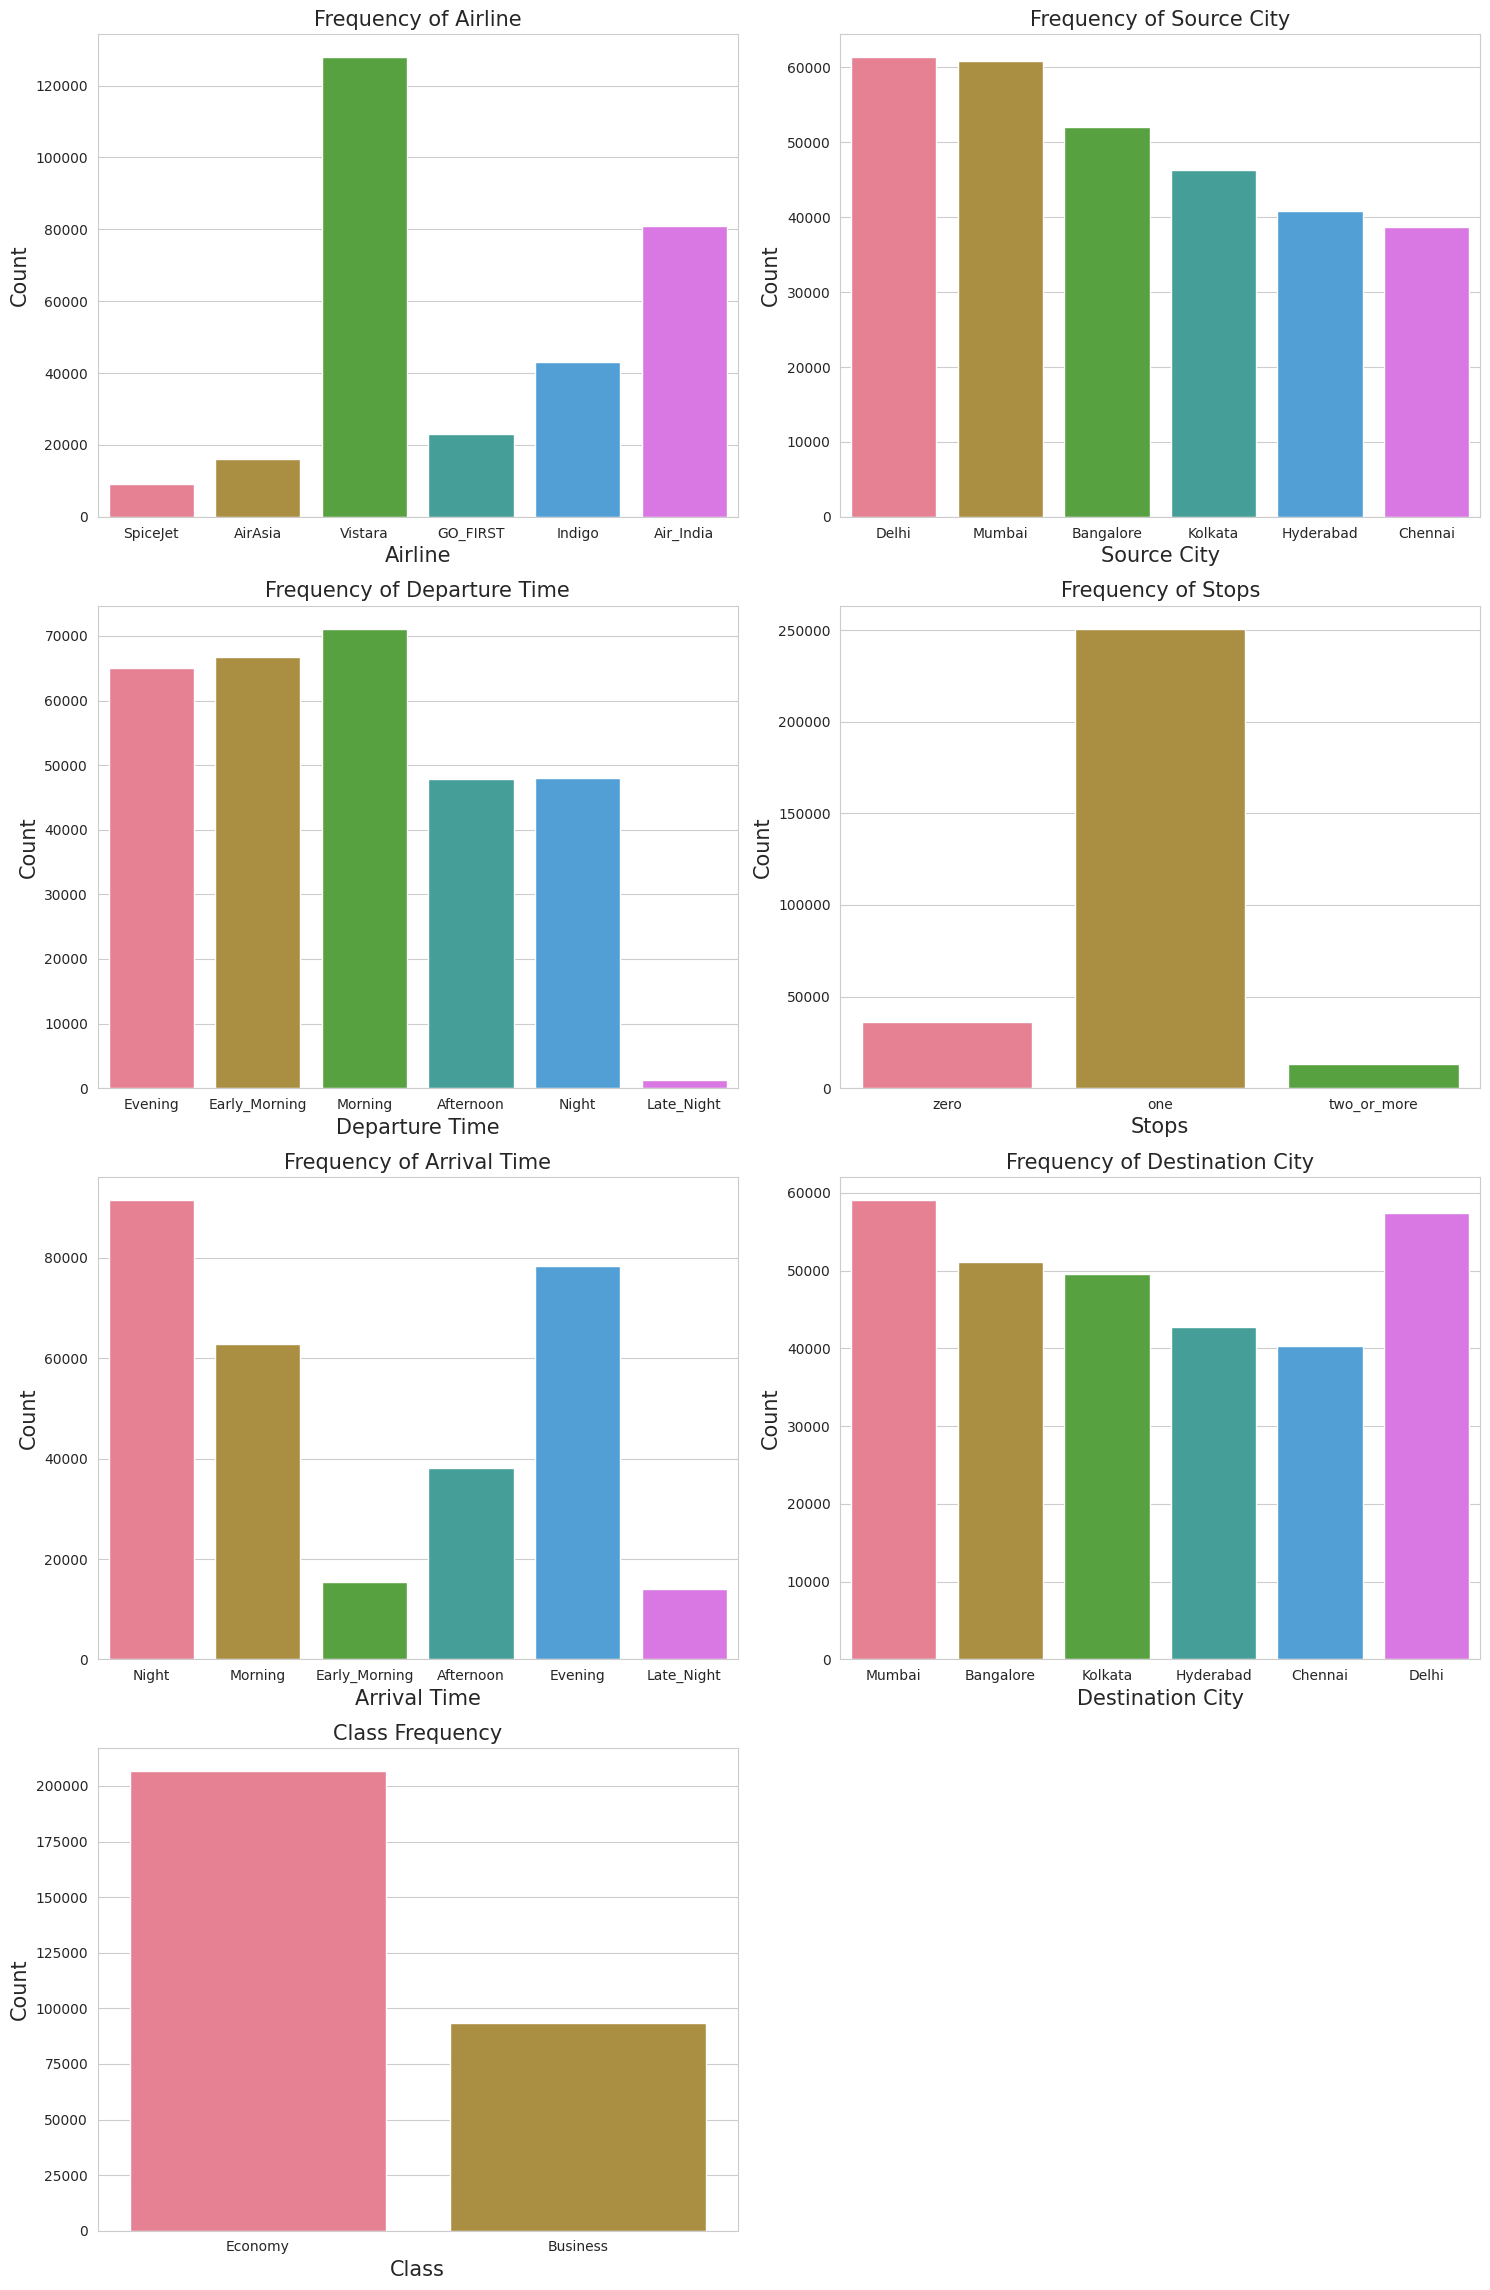

In [24]:
# Set Seaborn style
sns.set_style("whitegrid")

# Create figure
plt.figure(figsize=(15, 23))

# Define a color palette
palette = sns.color_palette("husl")

# First subplot: Frequency of Airline
plt.subplot(4, 2, 1)
sns.countplot(x=df["airline"], data=df, hue=df["airline"], palette=palette, legend=False)
plt.title("Frequency of Airline", fontsize=15)
plt.xlabel("Airline", fontsize=15)
plt.ylabel("Count", fontsize=15)

# Second subplot: Frequency of Source City
plt.subplot(4, 2, 2)
sns.countplot(x=df["source_city"], data=df, hue=df["source_city"], palette=palette, legend=False)
plt.title("Frequency of Source City", fontsize=15)
plt.xlabel("Source City", fontsize=15)
plt.ylabel("Count", fontsize=15)

# Third subplot: Frequency of Departure Time
plt.subplot(4, 2, 3)
sns.countplot(x=df["departure_time"], data=df, hue=df["departure_time"], palette=palette, legend=False)
plt.title("Frequency of Departure Time", fontsize=15)
plt.xlabel("Departure Time", fontsize=15)
plt.ylabel("Count", fontsize=15)

# Fourth subplot: Frequency of Stops
plt.subplot(4, 2, 4)
sns.countplot(x=df["stops"], data=df, hue=df["stops"], palette=palette, legend=False)
plt.title("Frequency of Stops", fontsize=15)
plt.xlabel("Stops", fontsize=15)
plt.ylabel("Count", fontsize=15)

# Fifth subplot: Frequency of Arrival Time
plt.subplot(4, 2, 5)
sns.countplot(x=df["arrival_time"], data=df, hue=df["arrival_time"], palette=palette, legend=False)
plt.title("Frequency of Arrival Time", fontsize=15)
plt.xlabel("Arrival Time", fontsize=15)
plt.ylabel("Count", fontsize=15)

# Sixth subplot: Frequency of Destination City
plt.subplot(4, 2, 6)
sns.countplot(x=df["destination_city"], data=df, hue=df["destination_city"], palette=palette, legend=False)
plt.title("Frequency of Destination City", fontsize=15)
plt.xlabel("Destination City", fontsize=15)
plt.ylabel("Count", fontsize=15)

# Seventh subplot: Class Frequency
plt.subplot(4, 2, 7)
sns.countplot(x=df["class"], data=df, hue=df["class"], palette=palette, legend=False)
plt.title("Class Frequency", fontsize=15)
plt.xlabel("Class", fontsize=15)
plt.ylabel("Count", fontsize=15)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


*   vistara has highest frequency i.e., it is used most
*   Delhi and Mumbai has the highest no. of passangers whether its departure on arrival
*  Most flights depart in Morning and Evening
*   There is generally one stop or no stop at during journey
*   Most flights have arrival time of Night and Evening
* Economy class has most number of passangers






In [25]:
df.drop(columns = ['flight'],inplace = True)

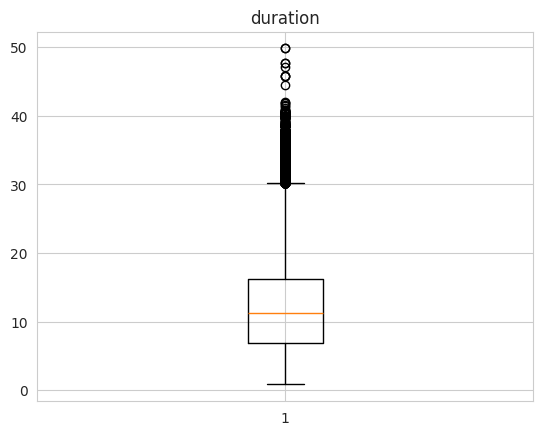

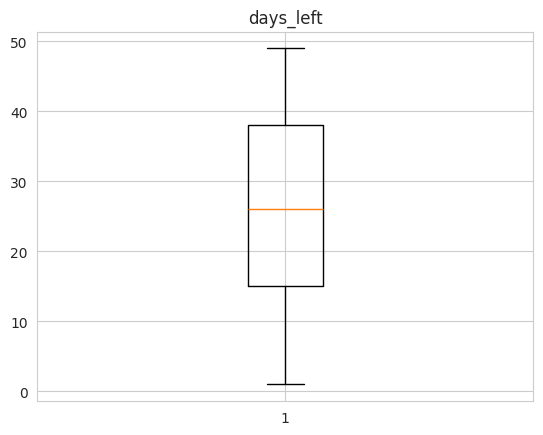

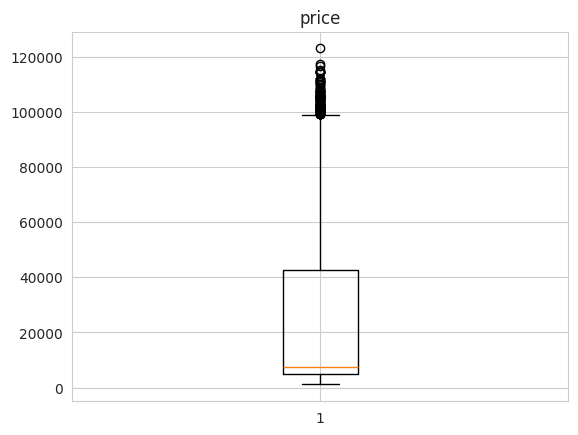

In [26]:
for i in df.columns:
    if df[i].dtype != 'O':
        plt.boxplot(df[i])
        plt.title(i)
        plt.show()

In [27]:
out_col = ['duration','price']

In [28]:
for col in out_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    LL = Q1 - IQR * 1.5
    UL = Q3 + IQR * 1.5
    df = df[(df[col] <= UL) & (df[col] >=LL)]

In [29]:
le = LabelEncoder()
for i in df.columns:
    if df[i].dtype == 'object':
        df[i] = le.fit_transform(df[i])
        print(f'Column Name : {i}')
        print("Original ---> Encoded")
        for original_class,encoded_value in zip(le.classes_,le.transform(le.classes_)):
            print(f'{original_class}->{encoded_value}')
        print()

Column Name : airline
Original ---> Encoded
AirAsia->0
Air_India->1
GO_FIRST->2
Indigo->3
SpiceJet->4
Vistara->5

Column Name : source_city
Original ---> Encoded
Bangalore->0
Chennai->1
Delhi->2
Hyderabad->3
Kolkata->4
Mumbai->5

Column Name : departure_time
Original ---> Encoded
Afternoon->0
Early_Morning->1
Evening->2
Late_Night->3
Morning->4
Night->5

Column Name : stops
Original ---> Encoded
one->0
two_or_more->1
zero->2

Column Name : arrival_time
Original ---> Encoded
Afternoon->0
Early_Morning->1
Evening->2
Late_Night->3
Morning->4
Night->5

Column Name : destination_city
Original ---> Encoded
Bangalore->0
Chennai->1
Delhi->2
Hyderabad->3
Kolkata->4
Mumbai->5

Column Name : class
Original ---> Encoded
Business->0
Economy->1



In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297921 entries, 0 to 300152
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           297921 non-null  int64  
 1   source_city       297921 non-null  int64  
 2   departure_time    297921 non-null  int64  
 3   stops             297921 non-null  int64  
 4   arrival_time      297921 non-null  int64  
 5   destination_city  297921 non-null  int64  
 6   class             297921 non-null  int64  
 7   duration          297921 non-null  float64
 8   days_left         297921 non-null  int64  
 9   price             297921 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 25.0 MB


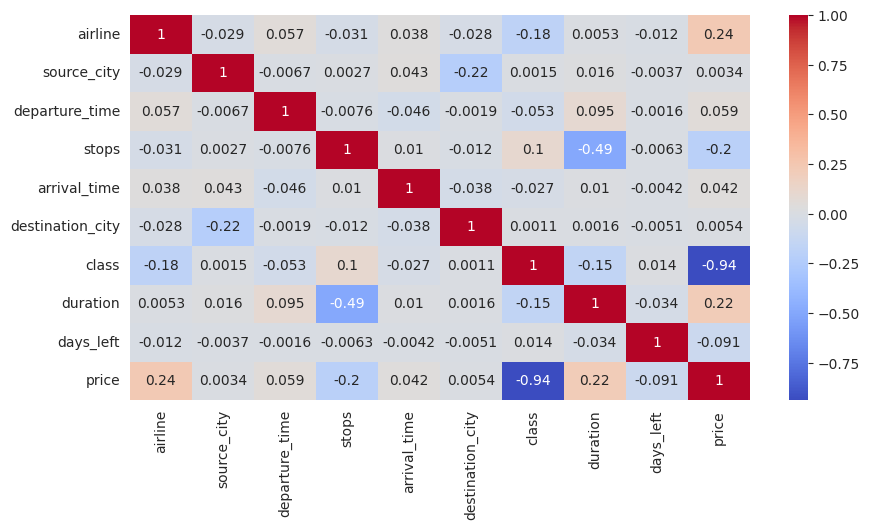

In [31]:
#Plotting the correlation graph to see the correlation between features and dependent variable.
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

In [32]:
# Feature Selection
# Selecting the features using VIF. VIF should be less than 5.

from statsmodels.stats.outliers_influence import variance_inflation_factor
col_list = []
for col in df.columns:
    if ((df[col].dtype != 'object') & (col != 'price')):
        col_list.append(col)

X = df[col_list]
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values,i) for i in range(len(X.columns))]
print(vif_data)

            feature       VIF
0           airline  3.409482
1       source_city  2.946912
2    departure_time  2.803413
3             stops  1.452338
4      arrival_time  3.690532
5  destination_city  2.892788
6             class  2.837463
7          duration  4.316253
8         days_left  3.998231


**MODEL BUILDING**

In [33]:
# Independent Variable
X = df.drop(columns=["price"])
# Dependent Variable
y = df['price']

In [34]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [35]:
# Standardization
from sklearn.preprocessing import StandardScaler
sc =StandardScaler()
x_train=sc.fit_transform(x_train)
x_test =sc.transform(x_test)

**LINEAR REGRESSION**

In [36]:
from sklearn.linear_model import LinearRegression
lr =LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
difference=pd.DataFrame(np.c_[y_test,y_pred], columns=["Actual_Value", "Predicted_Value"])
difference

,Actual_Value,Predicted_Value
0,4821.0,9943.287514
1,7450.0,7951.350244
2,70431.0,54405.770252
3,6632.0,8165.992455
4,47217.0,53258.624125
...,...,...
59580,55281.0,57730.794767
59581,9522.0,3915.421035
59582,6663.0,10317.465176
59583,51819.0,54381.484075


In [37]:
from sklearn.metrics import *
print('r2 Score : ', r2_score(y_test,y_pred))
print('Mean Absolute Error : ', mean_absolute_error(y_test,y_pred))
print('Mean Absolute Percentage Error (MAPE) : ', mean_absolute_percentage_error(y_test,y_pred))
print('Mean Squared Error (MSE) : ', mean_squared_error(y_test,y_pred))
print('Roor Mean Squared Error (RMSE) : ', np.sqrt(mean_squared_error(y_test,y_pred)))

r2 Score :  0.906413489386168
Mean Absolute Error :  4624.680638432378
Mean Absolute Percentage Error (MAPE) :  0.44130196573398256
Mean Squared Error (MSE) :  48275800.60388503
Roor Mean Squared Error (RMSE) :  6948.078914627052


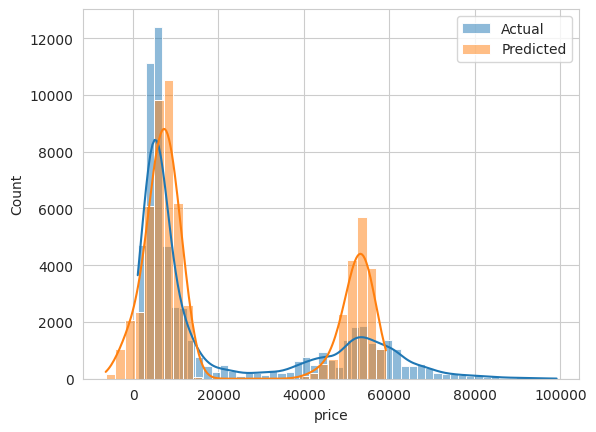

In [38]:
sns.histplot(y_test, label="Actual",  kde=True)
sns.histplot(y_pred, label="Predicted",  kde=True)
plt.legend()
plt.show()

There is too much variation in predictions as you can see.

**DECISION TREE REGRESSOR**

In [39]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(x_train,y_train)
y_pred=dt.predict(x_test)

print('r2 Score : ', r2_score(y_test,y_pred))
print('Mean Absolute Error : ', mean_absolute_error(y_test,y_pred))
print('Mean Absolute Percentage Error (MAPE) : ', mean_absolute_percentage_error(y_test,y_pred))
print('Mean Squared Error (MSE) : ', mean_squared_error(y_test,y_pred))
print('Roor Mean Squared Error (RMSE) : ', np.sqrt(mean_squared_error(y_test,y_pred)))

r2 Score :  0.9768947946272888
Mean Absolute Error :  1157.691432407485
Mean Absolute Percentage Error (MAPE) :  0.07450185794539789
Mean Squared Error (MSE) :  11918622.461386627
Roor Mean Squared Error (RMSE) :  3452.3357978891086


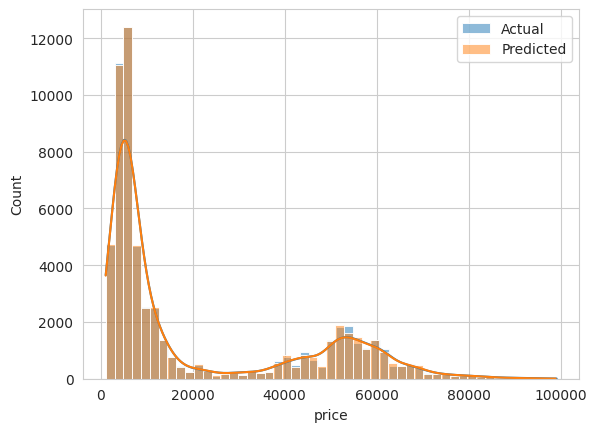

In [40]:
sns.histplot(y_test, label="Actual",  kde=True)
sns.histplot(y_pred, label="Predicted",  kde=True)
plt.legend()
plt.show()


The Error is much less compared to linear regression.

In [43]:
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor()
rfr.fit(x_train,y_train)
y_pred=rfr.predict(x_test)

print('r2 Score : ', r2_score(y_test,y_pred))
print('Mean Absolute Error : ', mean_absolute_error(y_test,y_pred))
print('Mean Absolute Percentage Error (MAPE) : ', mean_absolute_percentage_error(y_test,y_pred))
print('Mean Squared Error (MSE) : ', mean_squared_error(y_test,y_pred))
print('Roor Mean Squared Error (RMSE) : ', np.sqrt(mean_squared_error(y_test,y_pred)))


r2 Score :  0.9857583807179683
Mean Absolute Error :  1069.691618421263
Mean Absolute Percentage Error (MAPE) :  0.06971406817060265
Mean Squared Error (MSE) :  7346417.429460098
Roor Mean Squared Error (RMSE) :  2710.4275362864987


In [ ]:
sns.histplot(y_test, label="Actual",  kde=True)
sns.histplot(y_pred, label="Predicted",  kde=True)
plt.legend()
plt.show()


The Error is much less compared to linear regression and Decision Tree model. Therefore, we can conclude that the Random Forest model provides better predictive accuracy for the given dataset.
